#### Seq2Seq:
Designed for tasks involving sequential Data.
* Takes an input sequence, processes it, and generates an o/p sequence.
* Consists of:
  1. **ENCODER**
  2. **DECODER**
* Improved the quality of machine translation systems.

## word Embedding
* technique that translates a word into a list of numbers (a vector) so a computer can understand its meaning and context.

In [1]:
# !pip install gensim -U

In [2]:
from gensim.models import Word2Vec 
import matplotlib.pyplot as ply
from sklearn.decomposition import PCA

#### preare the data

In [3]:
corpus_text=[
    # --- TOPIC 1: FOOD & FRUITS ---
    "I eat mango and apple everyday",
    "Mango is a very sweet and delicious fruit",
    "Apple pie is a tasty dessert",
    "Banana is yellow and good for health",
    "Fruits like mango apple and banana are healthy",
    "I love eating pizza and burger for dinner",
    "Burger is a fast food",
    "Pizza contains cheese and tomato sauce",
    "I am hungry I want to eat food",
    "Restaurant serves delicious meals",
    "Vegetables and fruits are essential for diet",
    "Cook dinner in the kitchen",
    "Sweet desserts like cake and chocolate",
    
    # --- TOPIC 2: SPORTS & GAMES ---
    "Cricket is a popular sport in India",
    "Virat Kohli plays cricket for the team",
    "Football is played with a ball in a stadium",
    "Messi is a famous football player",
    "Players run fast to score a goal",
    "Tennis is played with a racket and ball",
    "The match was played in a big stadium",
    "The team won the championship trophy",
    "Athletes run in the olympics",
    "Bat and ball are used in cricket matches",
    "Score runs to win the cricket game",
    "The referee blew the whistle",

    # --- TOPIC 3: TECHNOLOGY & CODING ---
    "Python is a popular programming language",
    "Computers use binary code to process data",
    "Artificial Intelligence and machine learning are the future",
    "Data science involves statistics and algorithms",
    "Software developers write code in java and python",
    "The computer requires a keyboard and mouse",
    "Internet connects computers globally",
    "Deep learning models use neural networks",
    "Robots are built using engineering and ai",
    "The server stores massive amounts of data",
    "Programmers debug the software code",
    "Technology is advancing rapidly"
]

In [4]:
print(corpus_text)

['I eat mango and apple everyday', 'Mango is a very sweet and delicious fruit', 'Apple pie is a tasty dessert', 'Banana is yellow and good for health', 'Fruits like mango apple and banana are healthy', 'I love eating pizza and burger for dinner', 'Burger is a fast food', 'Pizza contains cheese and tomato sauce', 'I am hungry I want to eat food', 'Restaurant serves delicious meals', 'Vegetables and fruits are essential for diet', 'Cook dinner in the kitchen', 'Sweet desserts like cake and chocolate', 'Cricket is a popular sport in India', 'Virat Kohli plays cricket for the team', 'Football is played with a ball in a stadium', 'Messi is a famous football player', 'Players run fast to score a goal', 'Tennis is played with a racket and ball', 'The match was played in a big stadium', 'The team won the championship trophy', 'Athletes run in the olympics', 'Bat and ball are used in cricket matches', 'Score runs to win the cricket game', 'The referee blew the whistle', 'Python is a popular pro

### preprocess the data

In [5]:
import gensim
tokenize_text=[]
for sent in corpus_text:
    tokens=gensim.utils.simple_preprocess(sent)
    tokenize_text.append(tokens)   
tokenize_text

[['eat', 'mango', 'and', 'apple', 'everyday'],
 ['mango', 'is', 'very', 'sweet', 'and', 'delicious', 'fruit'],
 ['apple', 'pie', 'is', 'tasty', 'dessert'],
 ['banana', 'is', 'yellow', 'and', 'good', 'for', 'health'],
 ['fruits', 'like', 'mango', 'apple', 'and', 'banana', 'are', 'healthy'],
 ['love', 'eating', 'pizza', 'and', 'burger', 'for', 'dinner'],
 ['burger', 'is', 'fast', 'food'],
 ['pizza', 'contains', 'cheese', 'and', 'tomato', 'sauce'],
 ['am', 'hungry', 'want', 'to', 'eat', 'food'],
 ['restaurant', 'serves', 'delicious', 'meals'],
 ['vegetables', 'and', 'fruits', 'are', 'essential', 'for', 'diet'],
 ['cook', 'dinner', 'in', 'the', 'kitchen'],
 ['sweet', 'desserts', 'like', 'cake', 'and', 'chocolate'],
 ['cricket', 'is', 'popular', 'sport', 'in', 'india'],
 ['virat', 'kohli', 'plays', 'cricket', 'for', 'the', 'team'],
 ['football', 'is', 'played', 'with', 'ball', 'in', 'stadium'],
 ['messi', 'is', 'famous', 'football', 'player'],
 ['players', 'run', 'fast', 'to', 'score', 'goa

In [6]:
model=Word2Vec(sentences=tokenize_text,vector_size=5,window=5,min_count=1)
# help

In [7]:
model.wv['mango']

array([ 0.04879295, -0.01740606,  0.11169814, -0.05589752,  0.04511417],
      dtype=float32)

In [8]:
model.wv['technology']

array([ 0.0529478 ,  0.10717638, -0.04731978, -0.19072573,  0.09011398],
      dtype=float32)

In [9]:
model.wv.most_similar('fruit')

[('match', 0.8612329959869385),
 ('banana', 0.83371502161026),
 ('ball', 0.7952685356140137),
 ('engineering', 0.7702795267105103),
 ('india', 0.7479208111763),
 ('fast', 0.728485643863678),
 ('debug', 0.7034377455711365),
 ('played', 0.677760899066925),
 ('computers', 0.6620381474494934),
 ('run', 0.6583250164985657)]

In [10]:
import numpy as np
model.wv.most_similar('fruit')[1]

('banana', 0.83371502161026)

In [11]:
np.dot(model.wv['banana'],model.wv['fruit'])

0.055401884

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
# Comparing banana and fruit
cosine_similarity([model.wv['banana']], [model.wv['fruit']])

array([[0.8337151]], dtype=float32)

In [14]:
# Comparing computer and science
cosine_similarity([model.wv['computer']], [model.wv['science']])

array([[0.3236426]], dtype=float32)

In [15]:
# Comparing python and language
cosine_similarity([model.wv['python']], [model.wv['language']])

array([[-0.05968637]], dtype=float32)

In [16]:
# Comparing software and code
cosine_similarity([model.wv['software']], [model.wv['code']])

array([[-0.36367884]], dtype=float32)

In [17]:
# Comparing pizza and burger
cosine_similarity([model.wv['pizza']], [model.wv['burger']])

array([[0.0690997]], dtype=float32)

In [18]:
list1 = ['fruit','banana','football']
model.wv.doesnt_match(list1)

'football'

### Visualization

In [19]:
words_of_interest = [
    'apple', 'banana', 'fruit', 'burger', 'pizza',
    'cricket', 'football', 'tennis', 'player', 'ball',
    'python', 'java', 'computer', 'code', 'software'
]

In [20]:
import numpy as np
vectors = [model.wv[word] for word in words_of_interest]


In [21]:

vectors = np.array(vectors)


In [22]:
vectors

array([[-0.03163246,  0.00660935, -0.08215694, -0.15400968, -0.03056833],
       [ 0.10724822,  0.15541226, -0.11535514,  0.14861931,  0.13249679],
       [-0.03652918,  0.13024037, -0.05471214,  0.0973893 ,  0.1380665 ],
       [ 0.15817636,  0.1188664 , -0.03118432,  0.0300319 ,  0.03552626],
       [ 0.1562421 , -0.19012824, -0.00392282,  0.06925545, -0.01894839],
       [-0.06838538, -0.0186676 ,  0.11621643, -0.15113154, -0.07898313],
       [ 0.14483361,  0.1364461 ,  0.15146273, -0.07674447, -0.01187328],
       [-0.15986559, -0.15219465,  0.05912243, -0.05664993, -0.13825703],
       [-0.16111423,  0.12436502,  0.097147  ,  0.01524192,  0.05980222],
       [-0.16322044,  0.09034472, -0.08202619,  0.01552456,  0.1698906 ],
       [ 0.03253507,  0.00387419,  0.07068386,  0.00349434,  0.19188535],
       [-0.04306124,  0.17652217, -0.1066525 , -0.1630812 ,  0.13633455],
       [ 0.18778636,  0.09397707,  0.07993145, -0.12544605,  0.16895841],
       [-0.00664403, -0.1527955 ,  0.1

In [24]:
vectors.shape

(15, 5)

In [25]:
pca = PCA(n_components=2)

In [26]:
vectors_2d = pca.fit_transform(vectors)
vectors_2d

array([[-0.051311  , -0.14293656],
       [ 0.1873884 ,  0.11702009],
       [ 0.09927887,  0.02172822],
       [ 0.1070222 ,  0.07799624],
       [-0.15785208,  0.19651683],
       [-0.17588255, -0.12504151],
       [ 0.03028403,  0.02503517],
       [-0.31418988, -0.10728824],
       [-0.03687196, -0.09178694],
       [ 0.04990052, -0.08876143],
       [ 0.00923774,  0.0930664 ],
       [ 0.1531344 , -0.1699246 ],
       [ 0.11947861,  0.07306377],
       [-0.17014264,  0.20578825],
       [ 0.1505253 , -0.08447562]], dtype=float32)

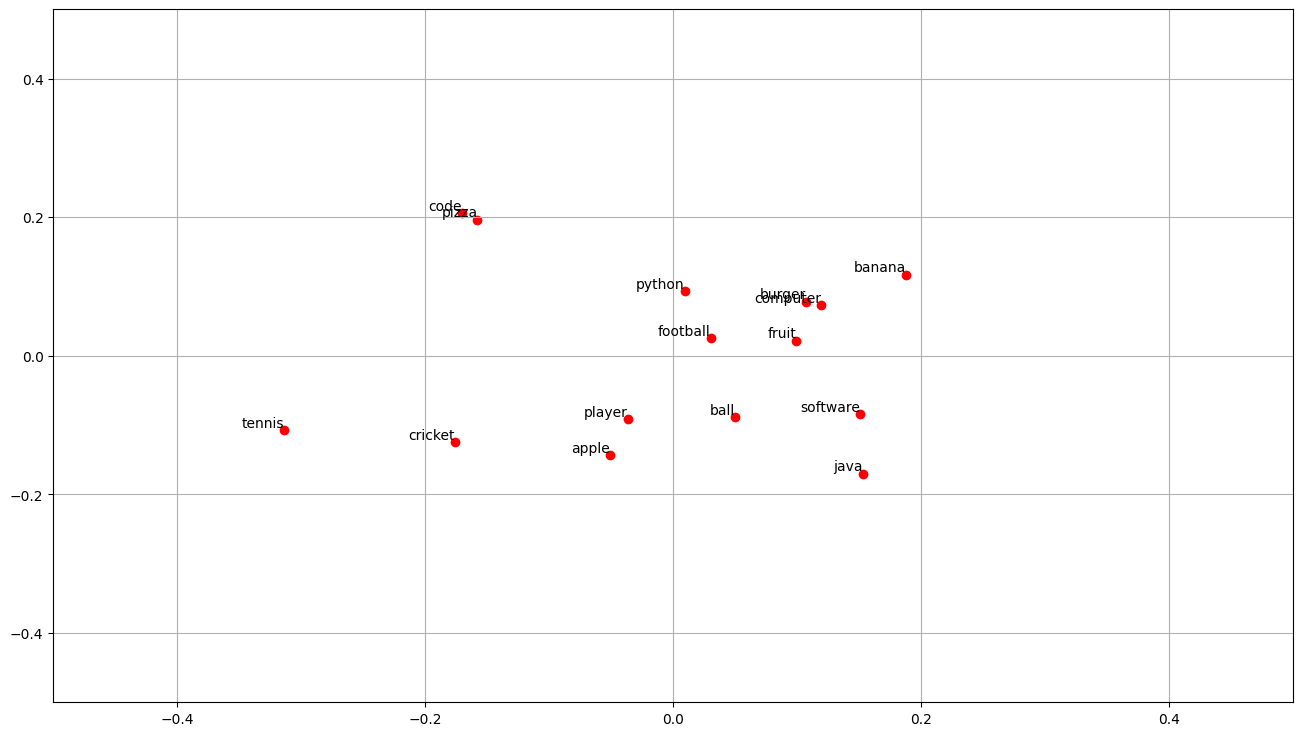

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))
plt.grid()
plt.ylim(-0.5,0.5)
plt.xlim(-0.5,0.5)
plt.scatter(vectors_2d[:,0], vectors_2d[:,1], color = 'r')
for i, word in enumerate(words_of_interest):
    plt.annotate(word, xy=(vectors_2d[i,0], vectors_2d[i,1]), ha ='right', va='bottom')